# Chapter 23 Lab — Localizing and Interpreting Results (Python)

Group analyses give you a statistic map; interpretation begins when you place that map in a **standard coordinate space** and relate it to **brain atlases and parcellations**. In this lab you will:

1. **Explore MNI space**: load the MNI152 template and convert between millimeter coordinates and voxel indices with the image affine
2. **Simulate a group activation map** at known MNI coordinates and overlay it on the template
3. **Build a toy parcellation** of the template — a stand-in for a real atlas
4. **Run an ROI analysis**: extract per-subject parcel averages and test them, comparing parcel-level with voxelwise inference
5. **Quantify circularity bias**: show by simulation that *post hoc* (circular) ROI selection inflates effects even in pure noise — and that split-half selection fixes it

Everything is simulated in template space, so no datasets are downloaded and every step has a known ground truth.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter environment with `numpy`, `scipy`, `matplotlib`, `scikit-learn`, `statsmodels`, `nibabel`, and `nilearn` installed. See the [chapter page](../ch23-localizing-and-interpreting-results.md) for the concepts behind each step.

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
# Setup — installs nilearn when it's missing (safe to re-run anywhere)
try:
    import nilearn  # noqa: F401 — already present on many local setups
except ImportError:
    import sys
    if "pyodide" in sys.modules:
        # Running in your browser (JupyterLite): install a browser-compatible version
        import piplite
        await piplite.install("nilearn==0.13.1")
    else:
        # Colab or local Python
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nilearn"])
print("nilearn ready:", __import__("nilearn").__version__)


nilearn ready: 0.14.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from scipy import stats
from scipy.ndimage import gaussian_filter

from nilearn.datasets import load_mni152_template
from nilearn import plotting
from sklearn.cluster import MiniBatchKMeans
from statsmodels.stats.multitest import multipletests

rng = np.random.default_rng(23)
np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__)

numpy 2.4.6


## Part 1 — MNI space: templates, affines, and coordinates

Reporting a result at MNI $(x, y, z) = (38, 22, -2)$ only means something because everyone's data have been warped to a shared **template**. The MNI152 template — an average of 152 co-registered T1 scans from young healthy adults — is bundled with nilearn, so we can load it without downloading anything.

Every NIfTI image carries an **affine matrix** that maps voxel indices $(i, j, k)$ to millimeter coordinates $(x, y, z)$ in the template's stereotaxic space. This little piece of bookkeeping is what makes coordinate reporting, atlas lookup, and cross-study comparison possible.

Image shape (voxels): (99, 117, 95)
Voxel size (mm):      (np.float32(2.0), np.float32(2.0), np.float32(2.0))
Affine (voxel -> mm):
 [[   2.    0.    0.  -98.]
 [   0.    2.    0. -134.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]


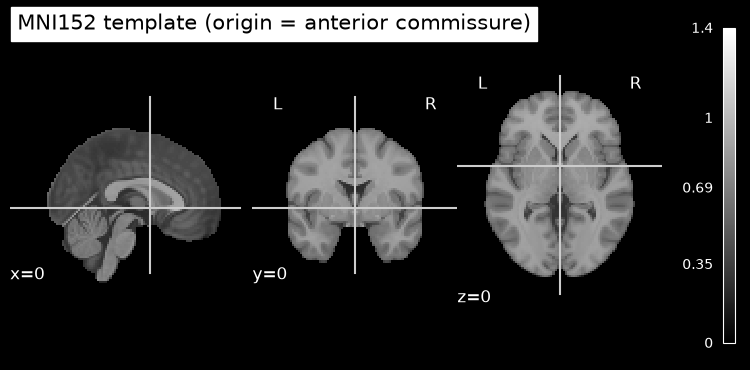

In [3]:
template = load_mni152_template(resolution=2)   # bundled with nilearn: no download

print("Image shape (voxels):", template.shape)
print("Voxel size (mm):     ", template.header.get_zooms())
print("Affine (voxel -> mm):\n", template.affine)

plotting.plot_anat(template, cut_coords=(0, 0, 0),
                   title="MNI152 template (origin = anterior commissure)")
plt.show()

The affine's diagonal gives the voxel size (2 mm here); the last column gives the mm coordinate of voxel $(0,0,0)$. Multiplying by the affine converts voxel indices to mm; multiplying by its inverse goes the other way. We will need both directions constantly — atlases and results are stored on voxel grids, but coordinates are reported in mm.

In [4]:
affine = template.affine
inv_affine = np.linalg.inv(affine)

def mm_to_voxel(xyz_mm):
    '''Convert an MNI (x, y, z) coordinate in mm to voxel indices (i, j, k).'''
    ijk = inv_affine @ np.append(xyz_mm, 1.0)
    return np.round(ijk[:3]).astype(int)

def voxel_to_mm(ijk):
    '''Convert voxel indices (i, j, k) to MNI mm coordinates.'''
    return (affine @ np.append(ijk, 1.0))[:3]

r_insula = np.array([38, 22, -2])          # right anterior insula (MNI, mm)
ijk = mm_to_voxel(r_insula)
print("MNI", r_insula, "mm  ->  voxel indices", ijk)
print("Round trip:", voxel_to_mm(ijk), "mm")

MNI [38 22 -2] mm  ->  voxel indices [68 78 35]
Round trip: [38. 22. -2.] mm


## Part 2 — A simulated group effect at known MNI coordinates

We now create a **ground-truth effect map**: three activation foci placed at MNI coordinates typical of a pain/salience contrast — dorsal anterior cingulate and bilateral anterior insula. Because we build it ourselves, we will later be able to check exactly which parcels *should* show effects.

The peak effect is 0.5 in units of the between-subject noise SD (a moderate effect size, $d = 0.5$ at the peak).

235,398 voxels in the brain mask


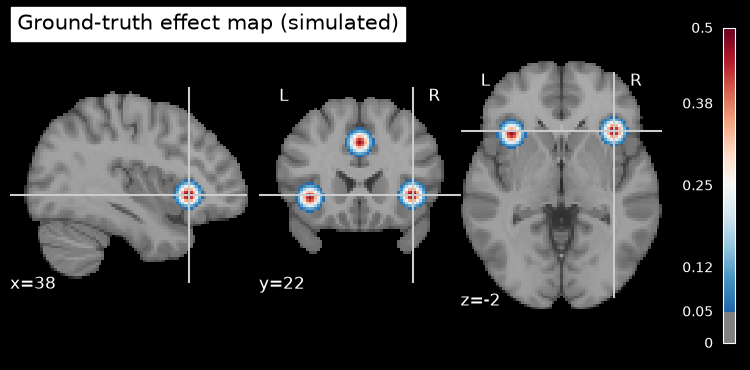

In [5]:
tdata = template.get_fdata()
brain_mask = tdata > 0.2 * tdata.max()          # crude brain mask from the template
print(f"{brain_mask.sum():,} voxels in the brain mask")

foci_mm = {"dACC":         (0, 20, 36),
           "R ant insula": (38, 22, -2),
           "L ant insula": (-36, 20, -4)}

truth = np.zeros(template.shape)
for name, xyz in foci_mm.items():
    truth[tuple(mm_to_voxel(xyz))] = 1.0
truth = gaussian_filter(truth, sigma=2.5)       # spread each focus over ~10 mm
truth = 0.5 * truth / truth.max()               # peak effect = 0.5 (noise SD = 1)
truth *= brain_mask

truth_img = nib.Nifti1Image(truth, affine)
plotting.plot_stat_map(truth_img, bg_img=template, threshold=0.05,
                       cut_coords=foci_mm["R ant insula"],
                       title="Ground-truth effect map (simulated)")
plt.show()

## Part 3 — Build a toy parcellation

A **parcellation** divides the brain into non-overlapping labeled regions. Real atlases derive their boundaries from histology (Jülich), functional connectivity (Yeo–Buckner, Schaefer), diffusion tractography (Brainnetome), meta-analysis (Neurosynth), or multiple modalities combined (the Glasser HCP atlas).

Here we build a deliberately naive one — 60 spatially compact parcels from k-means clustering of voxel *coordinates only*. It knows nothing about anatomy or function, but it plays the same computational role as a real atlas: an integer label image on the template grid, defined **independently of the data we will analyze**. That independence is what makes it legitimate for a priori ROI selection.

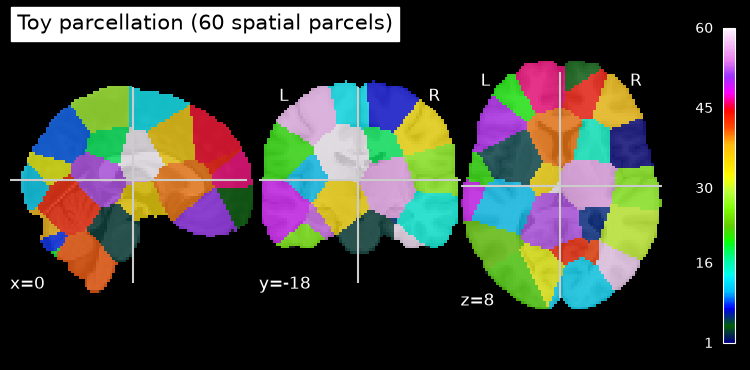

Parcels containing the true foci: {'dACC': 36, 'R ant insula': 24, 'L ant insula': 55}


In [6]:
ijk_brain = np.array(np.where(brain_mask)).T                 # in-brain voxel indices
xyz_brain = ijk_brain @ affine[:3, :3].T + affine[:3, 3]     # ... in mm

n_parcels = 60
km = MiniBatchKMeans(n_clusters=n_parcels, random_state=0, n_init=3,
                     batch_size=2048)
parcel_of_voxel = km.fit_predict(xyz_brain)                  # 0 .. n_parcels-1

label_data = np.zeros(template.shape, dtype=np.int32)
label_data[brain_mask] = parcel_of_voxel + 1                 # 0 = background
label_img = nib.Nifti1Image(label_data, affine)

plotting.plot_roi(label_img, bg_img=template,
                  title=f"Toy parcellation ({n_parcels} spatial parcels)")
plt.show()

# Which parcels contain our true foci? (ground truth for later)
true_parcels = {name: int(label_data[tuple(mm_to_voxel(xyz))])
                for name, xyz in foci_mm.items()}
print("Parcels containing the true foci:", true_parcels)

## Part 4 — ROI analysis: parcel averages vs. voxelwise tests

We simulate a group study: 20 subjects, each with a contrast map equal to the true effect (scaled by a subject-specific amplitude) plus independent noise. Then we analyze it two ways:

- **Voxelwise**: a one-sample t-test at every in-brain voxel (~230,000 tests)
- **ROI analysis**: average each subject's map within each parcel,
  $\bar{y}_{sj} = \frac{1}{|R_j|}\sum_{v \in R_j} y_{sv}$, then one t-test per parcel (60 tests)

Averaging over a parcel's voxels suppresses voxel-level noise, and testing 60 parcels instead of 230,000 voxels makes multiple-comparisons correction far less punishing.

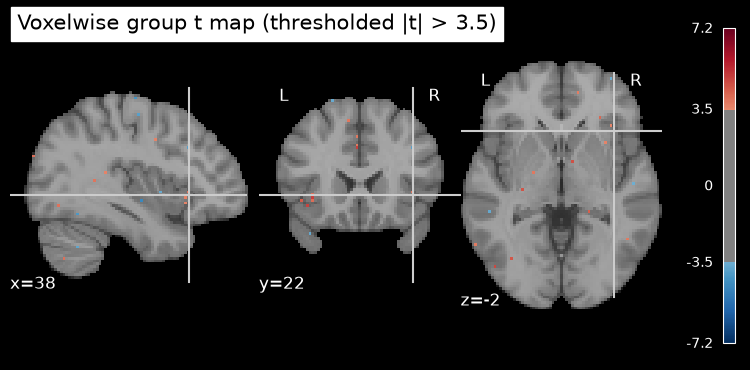

In [7]:
n_sub = 20
truth_vec = truth[brain_mask]                       # true effect per in-brain voxel
amp = 1 + 0.3 * rng.standard_normal(n_sub)          # subject amplitudes ~ N(1, 0.3)
noise = rng.standard_normal((n_sub, truth_vec.size))
subject_maps = amp[:, None] * truth_vec[None, :] + noise    # subjects x voxels

# --- Voxelwise group t map ---
t_vox = subject_maps.mean(0) / (subject_maps.std(0, ddof=1) / np.sqrt(n_sub))

t_vox_data = np.zeros(template.shape)
t_vox_data[brain_mask] = t_vox
plotting.plot_stat_map(nib.Nifti1Image(t_vox_data, affine), bg_img=template,
                       threshold=3.5, cut_coords=foci_mm["R ant insula"],
                       title="Voxelwise group t map (thresholded |t| > 3.5)")
plt.show()

Top parcels by t (FDR-significant marked *):
  parcel  36*  t =  8.64   p = 5.2e-08
  parcel  55*  t =  6.78   p = 1.8e-06
  parcel  24*  t =  4.78   p = 0.00013
  parcel  19   t =  2.14   p = 0.045
  parcel  45   t =  2.01   p = 0.059
  parcel  31   t =  1.98   p = 0.063
  parcel  35   t =  1.89   p = 0.074
  parcel  57   t =  1.77   p = 0.092

Parcels that truly contain foci: [24, 36, 55]


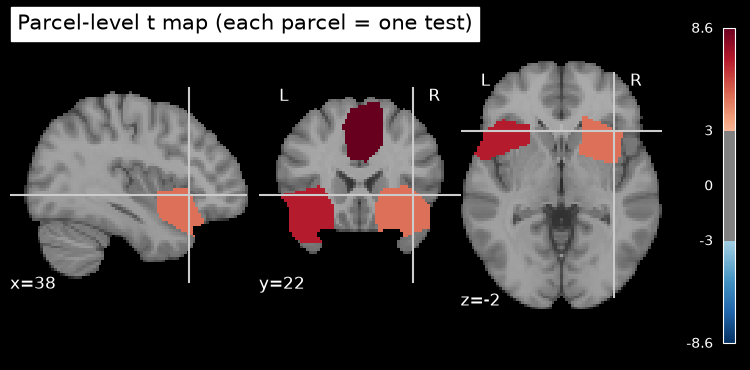

In [8]:
# --- Parcel-level ROI analysis ---
counts = np.bincount(parcel_of_voxel, minlength=n_parcels)
roi_means = np.vstack([
    np.bincount(parcel_of_voxel, weights=subject_maps[s], minlength=n_parcels) / counts
    for s in range(n_sub)
])                                                   # subjects x parcels

t_roi, p_roi = stats.ttest_1samp(roi_means, 0)
sig_fdr = multipletests(p_roi, alpha=0.05, method="fdr_bh")[0]

order = np.argsort(t_roi)[::-1]
print("Top parcels by t (FDR-significant marked *):")
for j in order[:8]:
    mark = "*" if sig_fdr[j] else " "
    print(f"  parcel {j + 1:3d}{mark}  t = {t_roi[j]:5.2f}   p = {p_roi[j]:.2g}")
print("\nParcels that truly contain foci:", sorted(set(true_parcels.values())))

# Paint the parcel t values back onto the brain for display
t_parcel_data = np.zeros(template.shape)
t_parcel_data[brain_mask] = t_roi[parcel_of_voxel]
plotting.plot_stat_map(nib.Nifti1Image(t_parcel_data, affine), bg_img=template,
                       threshold=3.0, cut_coords=foci_mm["R ant insula"],
                       title="Parcel-level t map (each parcel = one test)")
plt.show()

The FDR-significant parcels should be exactly (or nearly) the ones containing the simulated foci. Two things to notice:

- The parcel-level map is blocky — each parcel gets one value. That is the tradeoff: fewer, more powerful tests, at the cost of spatial resolution and the risk that an effect **straddles a parcel boundary** or occupies only a small fraction of a large parcel (diluting its average).
- In real analyses the parcels would come from a published atlas registered to the same MNI space, and you would report *which atlas and which version* you used — that is what makes ROI results comparable across studies.

## Part 5 — The circularity trap: a priori vs. post hoc ROI selection

Now the cautionary tale. Suppose a researcher runs a study with **no true effect anywhere**, looks at the parcel-level results, picks the parcel with the largest t statistic, and reports its effect size "because that's where the effect was."

That analysis is **circular** (non-independent): the same noise that makes a parcel the maximum also inflates its estimated effect. We quantify the bias over 2,000 simulated null studies, comparing:

- **A priori ROI**: parcel 1, chosen before seeing any data → unbiased
- **Circular ROI**: the parcel with the maximum t in the same data → biased

Mean estimated effect (truth = 0):  a priori +0.007   circular +0.489
'Significant' at p < .05 (truth = 0):  a priori 5.3%   circular 77.2%


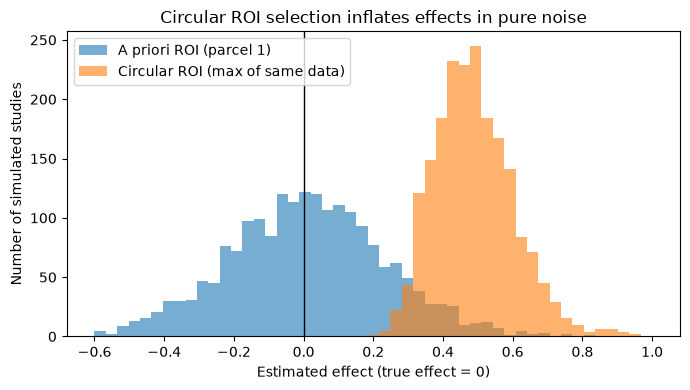

In [9]:
n_sims, n_sub_c, n_parc_c = 2000, 20, 60

null_data = rng.standard_normal((n_sims, n_sub_c, n_parc_c))   # truth = 0 everywhere
m  = null_data.mean(axis=1)
se = null_data.std(axis=1, ddof=1) / np.sqrt(n_sub_c)
t  = m / se

apriori_est  = m[:, 0]                                  # parcel chosen in advance
best         = np.argmax(t, axis=1)                     # parcel chosen post hoc
circular_est = m[np.arange(n_sims), best]
circular_t   = t[np.arange(n_sims), best]

t_crit = stats.t.ppf(0.975, df=n_sub_c - 1)
fp_apriori  = np.mean(np.abs(t[:, 0]) > t_crit)
fp_circular = np.mean(np.abs(circular_t) > t_crit)

print(f"Mean estimated effect (truth = 0):  a priori {apriori_est.mean():+.3f}   "
      f"circular {circular_est.mean():+.3f}")
print(f"'Significant' at p < .05 (truth = 0):  a priori {fp_apriori:.1%}   "
      f"circular {fp_circular:.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(-0.6, 1.0, 50)
ax.hist(apriori_est, bins, alpha=0.6, label="A priori ROI (parcel 1)")
ax.hist(circular_est, bins, alpha=0.6, label="Circular ROI (max of same data)")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("Estimated effect (true effect = 0)")
ax.set_ylabel("Number of simulated studies")
ax.set_title("Circular ROI selection inflates effects in pure noise")
ax.legend()
plt.tight_layout()
plt.show()

With no true effect anywhere, the circular estimate averages around $+0.4$ noise-SD units and is "significant" essentially every time — a textbook machine for manufacturing findings. The a priori ROI behaves exactly as statistics promises: centered on zero, with a ~5% false positive rate.

**The fix** is independence between selection and estimation. Besides using atlas ROIs defined in advance, a simple in-study remedy is **split-half selection**: choose the ROI with one half of the subjects, estimate the effect in the other half.

In [10]:
half1, half2 = null_data[:, :10], null_data[:, 10:]

t_half1 = half1.mean(1) / (half1.std(1, ddof=1) / np.sqrt(10))
sel = np.argmax(t_half1, axis=1)                    # select on half 1 ...
holdout_est = half2.mean(1)[np.arange(n_sims), sel] # ... estimate on half 2

print(f"Mean estimated effect in held-out half (truth = 0): {holdout_est.mean():+.3f}")
print(f"Compare: circular estimate in the same data:        {circular_est.mean():+.3f}")

Mean estimated effect in held-out half (truth = 0): +0.006
Compare: circular estimate in the same data:        +0.489


## Summary

- The **affine** links voxel grids to standard-space mm coordinates; MNI space is a shared frame built from group-average templates (MNI-305 → MNI-152 → ICBM-452).
- **Parcellations** turn the brain into named units of analysis. Real atlases encode histology, connectivity, meta-analysis, or multi-modal information — our toy k-means version shows the mechanics.
- **ROI analysis** (parcel averaging + one test per region) trades spatial resolution for power and a lighter multiple-comparisons burden.
- ROI selection must be **independent** of the data being tested: use a priori atlas ROIs, independent contrasts or datasets, or split-half/cross-validated selection. Circular selection inflates effects even in pure noise.

**Explore further.** Nilearn's `nilearn.datasets` module can fetch real atlases (Schaefer, Harvard–Oxford, Yeo, Destrieux) and `nilearn.maskers.NiftiLabelsMasker` automates parcel extraction on real data. Neurosynth (neurosynth.org), Neuroquery (neuroquery.org), and neuromaps offer meta-analytic and multi-modal annotation; the CANlab tools (canlab.github.io) mirror this workflow in MATLAB with `atlas` objects and automatic labeling via `region.table()`.